In [1]:
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

from synthetic_profiles import PVProfile, HydroProfile, DrinkingWaterProfile

# Daten einlesen

Die gelieferte Datengrundlage umfasst Erzeugungs- und Verbrauchsdaten für Zählerpunkte in der EEG in 15-minütiger Auflösung. Die Daten sind in csv files nach monaten aggregiert.

Im Folgenden werden
* diese files eingelesen (umständliches Format mit mehreren Header Zeilen),
* die monatlichen Zeitreihen in einen gesammelten Dataframe zusammengefasst, und
* Summen aller Zählpunkte für Erzeugung und Verbrauch der gesamten EEG erstellt.

In [7]:
# Lese alle CSV-Dateien aus dem Verzeichnis
files = glob(r'data\EEG Terfens\RC*.csv')

# Initialisiere eine Liste zum Speichern der DataFrames
dfs = []

# Verarbeite jede Monats-Datei einzeln
for file in files:
    # Schritt 1: Lese die ersten 2 Zeilen ohne Header, um pandas automatische Umbenennung zu vermeiden
    raw_data = pd.read_csv(file, sep=';', header=None, nrows=2)
    
    # Schritt 2: Extrahiere Originalspaltennamen (Zeile 0) und Zählpunkte IDs (Zeile 1)
    original_headers = raw_data.iloc[0].tolist()
    id_strings = raw_data.iloc[1].tolist()
    
    # Schritt 3: Erzeuge neue Spaltennamen durch Kombination von Header und IDs
    new_column_names = []
    for header, id_string in zip(original_headers, id_strings):
        if pd.notna(id_string) and str(id_string).strip():
            new_col_name = f"{header}_{id_string}"
        else:
            new_col_name = str(header)
        new_column_names.append(new_col_name)
    
    # Schritt 4: Lese die eigentlichen Daten ab Zeile 2 (überspringe Header- und ID-Zeilen)
    df = pd.read_csv(file, sep=';', decimal=',', header=None, skiprows=2)
    
    # Schritt 5: Wende die neuen Spaltennamen an
    df.columns = new_column_names
    
    dfs.append(df)

# Zusammenführen aller monatlichen DataFrames in einen einzigen DataFrame
merged_df = pd.concat(dfs)
merged_df['Zeitpunkt'] = pd.to_datetime(merged_df['Zeitpunkt'], format='%d.%m.%Y, %H:%M:%S')
merged_df = merged_df.set_index('Zeitpunkt').sort_index()

# Aufsummieren der Zählpunkte in der jeweiligen Daten-Kategorie
gb_mask = merged_df.columns.str.contains('Gesamtbezug')
merged_df['SUMME_Gesamtsbezug [kWh]'] = merged_df.loc[:, gb_mask].sum(axis=1)
rb_mask = merged_df.columns.str.contains('Restbezug')
merged_df['SUMME_Restbezug [kWh]'] = merged_df.loc[:, rb_mask].sum(axis=1)
bez_mask = merged_df.columns.str.contains('bezogen')
merged_df['SUMME_Effektiv aus Gemeinschaft bezogen [kWh]'] = merged_df.loc[:, bez_mask].sum(axis=1)
gl_mask = merged_df.columns.str.contains('Gesamtlieferung ')
merged_df['SUMME_Gesamtlieferung [kWh]'] = merged_df.loc[:, gl_mask].sum(axis=1)
rl_mask = merged_df.columns.str.contains('Restlieferung ')
merged_df['SUMME_Restlieferung [kWh]'] = merged_df.loc[:, rl_mask].sum(axis=1)
gel_mask = merged_df.columns.str.contains('geliefert ')
merged_df['SUMME_Effektiv an Gemeinschaft geliefert [kWh]'] = merged_df.loc[:, gel_mask].sum(axis=1)

# Extrahieren der aufsummierten Daten in ein neues DataFrame
df_sum = merged_df.iloc[:,-6:]

# Optional: Speichern der aufsummierten Daten in eine Excel-Datei
# df_sum.to_excel(r'EEG_Eben_am_Achensee_Summen.xlsx') 

# Umbenennen der Spalten für besseres handling
df_sum.rename(columns={
    'SUMME_Gesamtsbezug [kWh]': 'bez_ges',                  # Gesamter Stromverbrauch aller Zählpunkte
    'SUMME_Restbezug [kWh]': 'bez_rest',                    # Strombezug aus dem Netz (ohne Gemeinschaftsanteil)
    'SUMME_Effektiv aus Gemeinschaft bezogen [kWh]': 'bez_eff', # Effektiver Strombezug aus der Gemeinschaft
    'SUMME_Gesamtlieferung [kWh]': 'lief_ges',              # Gesamteinspeisung aller Zählpunkte
    'SUMME_Restlieferung [kWh]': 'lief_rest',               # Restliche Einspeisung ins Netz (ohne Gemeinschaftsanteil)
    'SUMME_Effektiv an Gemeinschaft geliefert [kWh]': 'lief_eff' # Effektive Einspeisung in die Gemeinschaft
    }, inplace=True)

In [8]:
merged_df.columns.str.contains('Gesamtbezug').sum()

25

Als Qualitätskontrolle werden noch Differenzen berechnet um zu überprüfen, ob die Daten in sich bilanziell stimmig sind. Gesamtbezug bzw. -lieferung von und an die EEG müssen sich mit Netzbezug/einspeisung und EEG-internem Bezug/Einspeisung ausgleichen: 

Differenz = 0

In [9]:
# Annahme: Gesamtbezug = Netzbezug + Gemeinschaftsbezug
df_sum['bez_diff'] = (df_sum['bez_rest'] + df_sum['bez_eff']) - df_sum['bez_ges']
# Annahme: Gesamtlieferung = Netzeinspeisung + Gemeinschaftseinspeisung
df_sum['lief_diff'] = (df_sum['lief_rest'] + df_sum['lief_eff']) - df_sum['lief_ges']

# maximale Abweichungen prüfen
df_sum['bez_diff'].max(), df_sum['lief_diff'].max()

(7.105427357601002e-15, 7.105427357601002e-15)

# Simulation

Ziel ist es, eine Konfiguration von PV-Leistung und Batterie-Kapazität zu finden, mit der sich die EEG einen großteil des Jahres (~75% der Tage) komplett selbst versorgen kann. An diesen Tagen soll der Netzbezug also 0 sein.

Dafür wir eine Simulation basierend auf den vorliegenden Daten erstellt. Die Rechenschritte sind:


In [10]:
def simulate(pv_base, load, pv_scale=1.0, storage=0.0, c_rate=1.0, 
             roundtrip_eff=0.9, allow_grid_charge=False):
    """
    Simuliere Energieflüsse und gib einen nach Zeitstempel indexierten DataFrame zurück.
    - pv_base, load: pandas Series indexiert mit Zeitstempeln, kWh pro Intervall
    - pv_scale: Faktor um EEG Erzeugungs-zeitreihe (pv_base) zu skalieren (1.0 = vorhandene PV)
    - storage: nutzbare Energiespeicherkapazität (kWh)
    - c_rate: Lade-/Entladeleistung relativ zur Kapazität (1.0 -> Leistung = Kapazität / 1h)
    - roundtrip_eff: Rundwirkungsgrad (Zahl zwischen 0 und 1)
    - allow_grid_charge: falls True, darf die Batterie aus dem Netz geladen werden (Standard False)

    Rückgabe: pandas DataFrame indexiert mit den Eingabezeitstempeln mit Spalten:
      'pv', 'load', 'net', 'grid_import', 'grid_export', 'soc',
      'battery_charge', 'battery_discharge'.
    Eine Zusammenfassungs-Dictionary mit aggregierten Kennzahlen wird in df.attrs['summary'] gespeichert.
    """
    # Generiere Grundvariablen
    dt_h = (load.index[1] - load.index[0]).total_seconds() / 3600.0 # Zeitschritt in Stunden
    pv = pv_base * pv_scale # skalierte PV-Erzeugung
    load = load # EEG-Verbrauch
    index = load.index # Zeitindex
    n = len(index) # Anzahl Zeitschritte

    # Initialisiere Speicher- und Ergebnisvariablen
    soc = 0.0  # Anfangs-Ladezustand (kWh)
    soc_series = np.zeros(n) # Ladezustand pro Intervall (kWh)
    grid_import = np.zeros(n) # Netzbezug pro Intervall (kWh)
    grid_export = np.zeros(n) # Überschusseinspeisung pro Intervall (kWh)
    battery_charge = np.zeros(n) # Batterie-Ladung pro Intervall (kWh)
    battery_discharge = np.zeros(n) # Batterie-Entladung pro Intervall (kWh)

    # Teile den Rundwirkungsgrad in Lade-/Entladefaktoren (Quadratwurzel)
    eff_ch = eff_d = np.sqrt(roundtrip_eff) if roundtrip_eff > 0 else 1.0
    p_limit = storage * c_rate * dt_h  # max kWh pro Intervall für Laden/Entladen

    # Simuliere Zeitschritte
    for i in range(n):
        p = pv.iloc[i]
        l = load.iloc[i]
        net = p - l # positiver Wert = Überschuss, negativer Wert = Defizit

        if net >= 0:
            # Überschuss PV: lade Batterie zuerst mit PV
            charge_from_pv = min(net, p_limit, storage - soc)
            soc += charge_from_pv * eff_ch # Ladeeffizienz anwenden
            battery_charge[i] = charge_from_pv
            # verbleibender Überschuss wird ins Netz eingespeist
            export = net - charge_from_pv
            grid_export[i] = max(0.0, export)
            grid_import[i] = 0.0
        else:
            # Defizit: versuche Batterie zu entladen
            needed = -net
            # verfügbare Entladeleistung (nach Effizienz) begrenzt durch p_limit und soc
            max_discharge_out = min(p_limit, soc * eff_d)
            discharge_out = min(needed, max_discharge_out)
            # Ladezustand entsprechend reduzieren (Wirkungsgrad beachten)
            if discharge_out > 0:
                soc -= discharge_out / eff_d
                battery_discharge[i] = discharge_out
                needed -= discharge_out
            # verbleibender Bedarf wird aus dem Netz bezogen
            if needed > 1e-12:
                grid_import[i] = needed
                if allow_grid_charge:
                    # optional: Laden aus dem Netz erlauben (für dieses Ziel selten sinnvoll)
                    # standardmäßig nicht verwendet
                    pass
            else:
                grid_import[i] = 0.0
        soc_series[i] = soc

    # Baue DataFrame mit Zeitindex
    df = pd.DataFrame({
        'pv': pv.values,
        'load': load.values,
        'net': pv.values - load.values,
        'grid_import': grid_import,
        'grid_export': grid_export,
        'soc': soc_series,
        'battery_charge': battery_charge,
        'battery_discharge': battery_discharge,
    }, index=index)

    # Zusammenfassende Kennzahlen in attrs speichern
    timesteps_with_import = int(np.sum(df['grid_import'] > 1e-9))
    days_with_import = timesteps_with_import * dt_h / 24.0
    frac_with_import = timesteps_with_import / n
    annual_import_energy = float(df['grid_import'].sum())
    annual_export_energy = float(df['grid_export'].sum())
    pv_total = float(df['pv'].sum())
    pv_used = pv_total - annual_export_energy
    curtailment = 0.0

    summary = {
        'timesteps_with_import': timesteps_with_import,
        'days_with_import': float(days_with_import),
        'frac_with_import': float(frac_with_import),
        'annual_import': annual_import_energy,
        'annual_export': annual_export_energy,
        'pv_total': pv_total,
        'pv_curtailment': curtailment
    }
    df.attrs['summary'] = summary
    return df

array([<Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>,
       <Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>,
       <Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>,
       <Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>],
      dtype=object)

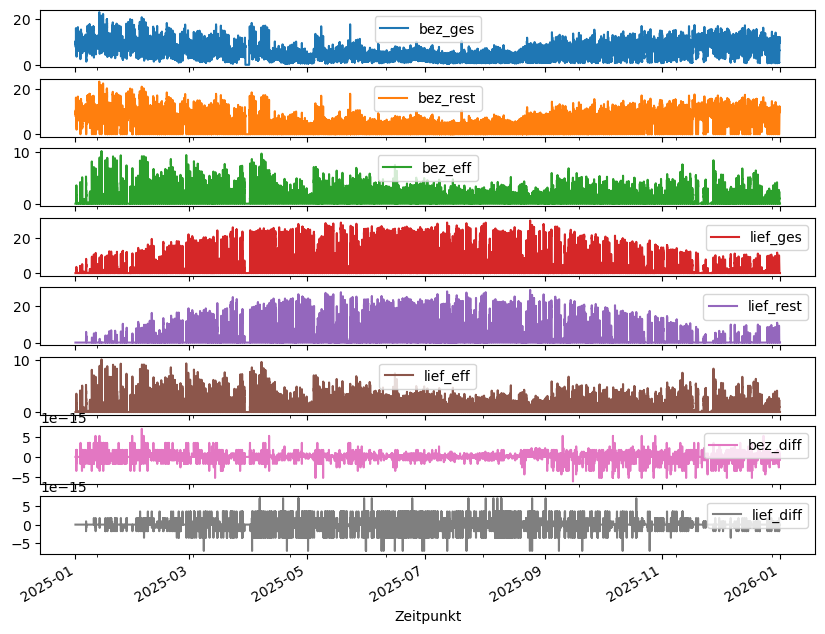

In [11]:
df_sum.plot(subplots=True, figsize=(10,8))

In [12]:
# Zeitreihen konfigurieren (angenommen df_sum Spalten sind in kWh pro 15-min Intervall)
df_slice = df_sum.loc['2025-02-01':'2025-12-31']  # Beispiel: nur Daten für 2025 verwenden
load = df_slice['bez_ges'].fillna(0)   # Verbrauch der Gemeinschaft pro Intervall (kWh)
pv_base = df_slice['lief_ges'].fillna(0)   # bestehende PV-Erzeugung pro Intervall (kWh)

In [15]:
load.index

DatetimeIndex(['2025-02-01 00:00:00', '2025-02-01 00:15:00',
               '2025-02-01 00:30:00', '2025-02-01 00:45:00',
               '2025-02-01 01:00:00', '2025-02-01 01:15:00',
               '2025-02-01 01:30:00', '2025-02-01 01:45:00',
               '2025-02-01 02:00:00', '2025-02-01 02:15:00',
               ...
               '2025-12-31 21:30:00', '2025-12-31 21:45:00',
               '2025-12-31 22:00:00', '2025-12-31 22:15:00',
               '2025-12-31 22:30:00', '2025-12-31 22:45:00',
               '2025-12-31 23:00:00', '2025-12-31 23:15:00',
               '2025-12-31 23:30:00', '2025-12-31 23:45:00'],
              dtype='datetime64[ns]', name='Zeitpunkt', length=32064, freq=None)

{'timesteps_with_import': 17207, 'days_with_import': 179.23958333333334, 'frac_with_import': 0.5366454590818364, 'annual_import': 130637.07022000002, 'annual_export': 68708.84522999999, 'pv_total': 124708.71500000001, 'pv_curtailment': 0.0}


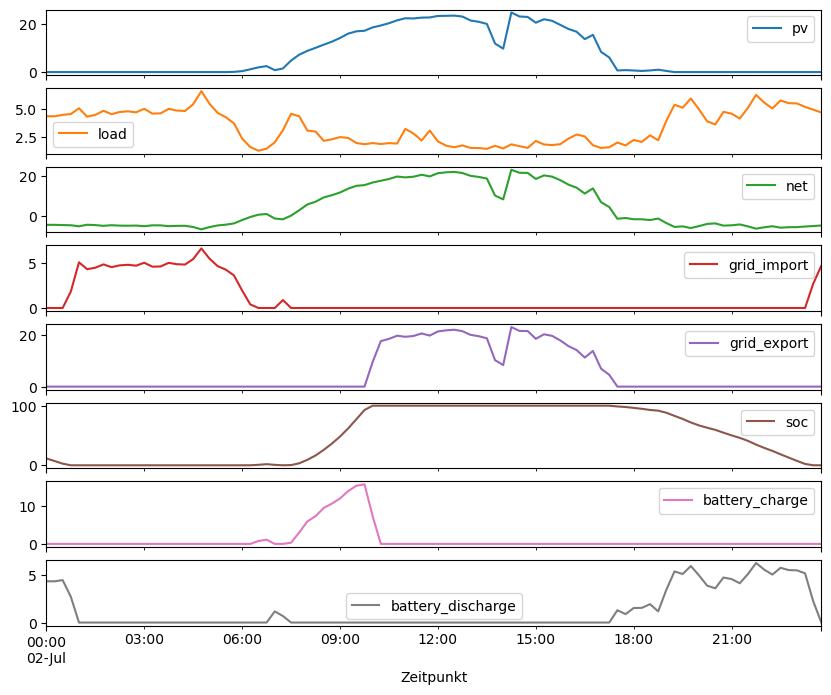

In [13]:
# Beispiel-Simulation mit 100 kWh Speicher
result = simulate(pv_base, load, pv_scale=1, storage=100, 
                  c_rate=1, roundtrip_eff=1)
result.loc['2025-07-02':'2025-07-02'].plot(subplots=True, figsize=(10,8))
print(result.attrs['summary'])

In [8]:
# grid search beispiel: PV scale 1 bis 10, batterie 0 bis 200 kWh.
pv_scales = np.arange(1, 100, 10) # mögliche PV-Skalierungen
storage_grid = np.arange(0, 2000, 100) # mögliche Speichergrößen in kWh

# Simuliere alle Kombinationen und speichere Ergebnisse
results = []
for pv_s, stor in tqdm(list(itertools.product(pv_scales, storage_grid)), desc='Grid search ausführen'):
    r = simulate(pv_base, load, pv_scale=pv_s, storage=stor,
                 c_rate=1, roundtrip_eff=1)
    results.append(dict(pv_scale=pv_s, storage=stor, **r.attrs['summary'], timeseries=r))

# Ergebnisse in DataFrame umwandeln
res_df = pd.DataFrame(results)

# Check, welche Kombinationen die Bedingung <=25% Zeitschritte mit Netzbezug erfüllen
candidates = res_df[res_df['frac_with_import'] <= 0.25].sort_values(['storage','pv_scale'])

if not candidates.empty:
    best = candidates.iloc[0]
    print("Example candidate (pv_scale, storage, frac_with_import):", best[['pv_scale','storage','frac_with_import']].to_dict())
else:
    print("No candidate found in grid — increase search ranges or allow higher PV/ storage.")


Grid search ausführen: 100%|██████████| 200/200 [00:35<00:00,  5.67it/s]

Example candidate (pv_scale, storage, frac_with_import): {'pv_scale': 31, 'storage': 300, 'frac_with_import': 0.24941556655665567}


array([<Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>,
       <Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>,
       <Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>,
       <Axes: xlabel='Zeitpunkt'>, <Axes: xlabel='Zeitpunkt'>],
      dtype=object)

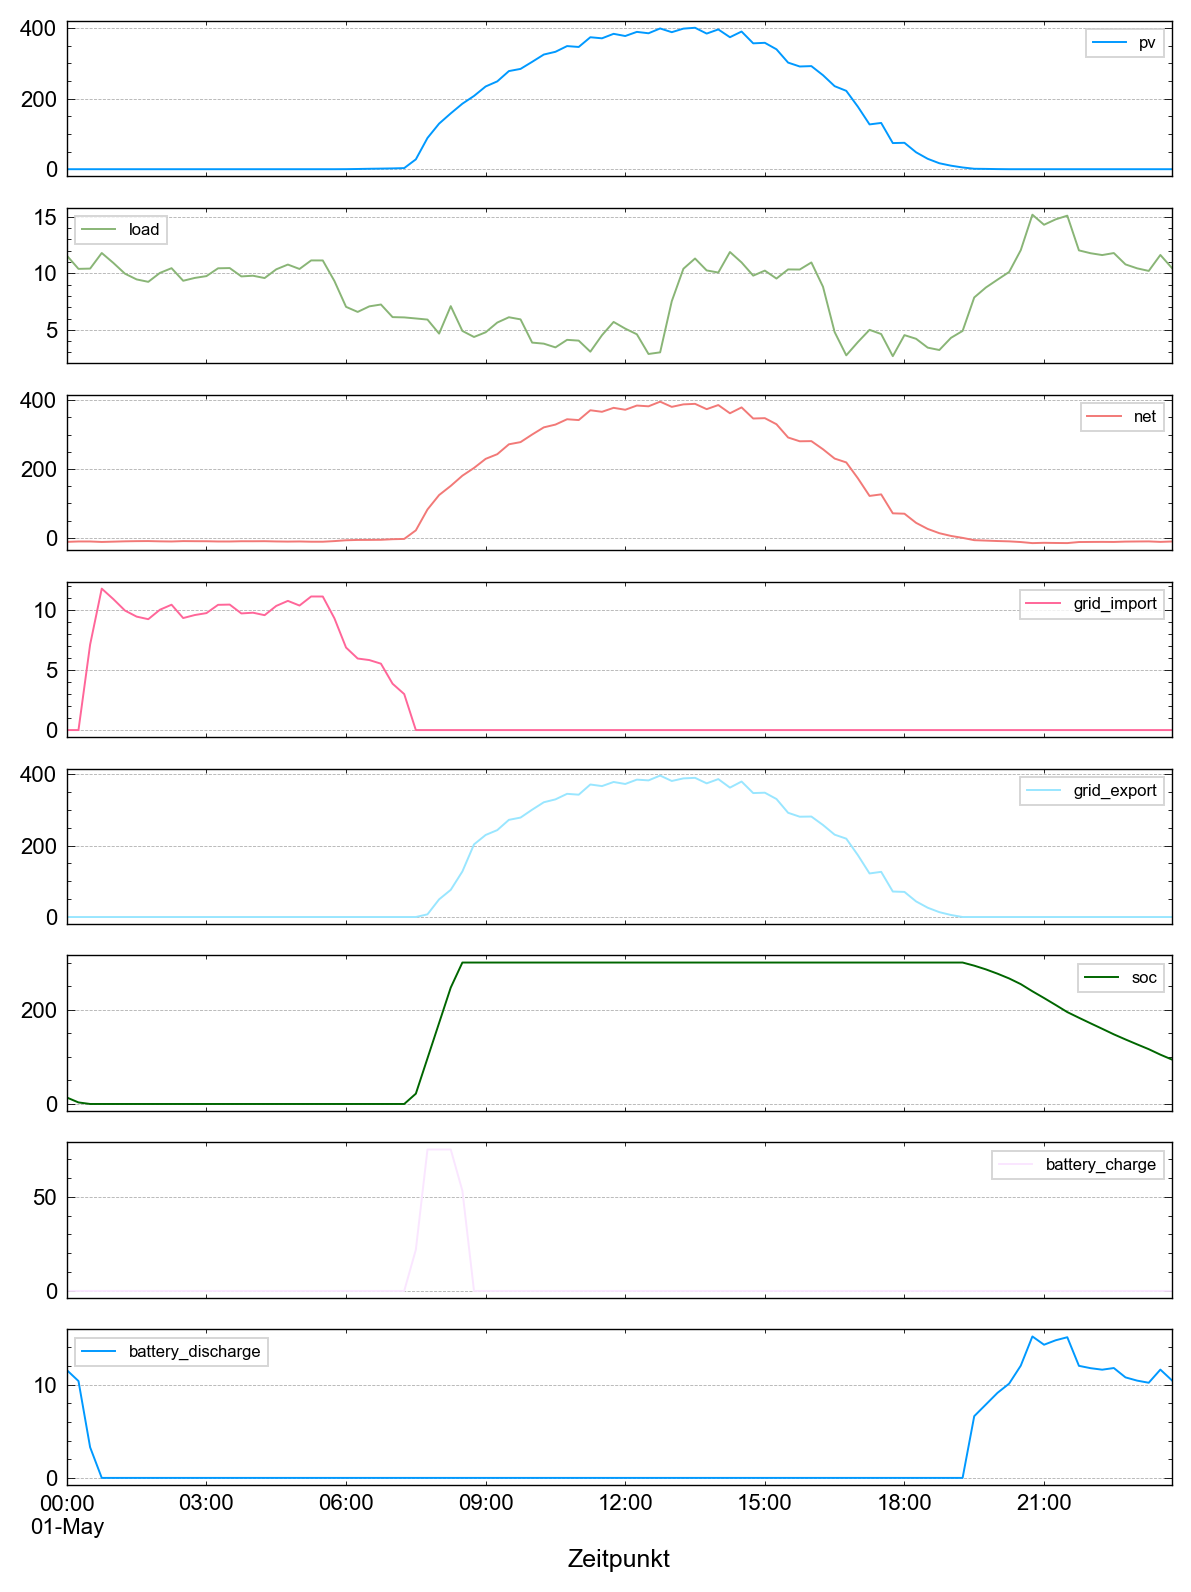

In [14]:
best.timeseries.loc['2025-05-01':'2025-05-01'].plot(subplots=True, figsize=(6,8))